In [ ]:
import pandas as pd

# Mostrar todas las columnas sin truncar
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)

df = pd.read_csv('streamers.csv')
df2 = pd.read_csv('streamers_global.csv')

In [2]:
def eda_basico(df):
    print("🔍 Primeras filas del DataFrame:")
    display(df.head())

    print("🔍 Últimas filas del DataFrame:")
    display(df.tail())

    print("📌 Filas Aleatorias:")
    display(df.sample(n=5))

    print("📐 Dimensiones:")
    print(f"{df.shape[0]} filas y {df.shape[1]} columnas\n")


    print("📊 Tipos de datos por columna:")
    display(df.dtypes.rename("Tipo").to_frame())

    print("📉 Descripción de columnas numéricas:")
    display(df.describe().T)

    print("🔤 Descripción de columnas categóricas:")
    display(df.describe(include=["O"]))

    print("🚫 Valores nulos por columna:")
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    if len(nulos) > 0:
        display(pd.DataFrame({
            "Nulos": nulos,
            "Porcentaje (%)": (nulos / len(df) * 100).round(2)
        }))
    else:
        print("No hay valores nulos.\n")

    print("🗑️ Columnas constantes:")
    constantes = [col for col in df.columns if df[col].nunique() == 1]
    if constantes:
        display(pd.DataFrame({
            "Columna": constantes,
            "Valor único": [df[col].unique()[0] for col in constantes],
            "Acción": ["Eliminar en Fase 2"] * len(constantes)
        }))
    else:
        print("No hay columnas constantes.\n")

    print("📎 Filas duplicadas:")
    dup_count = df.duplicated().sum()

    if dup_count > 0:
        print(f"Duplicadas: {dup_count}")
        print("Ejemplo de duplicados:")
        display(df[df.duplicated()].head())
    else:
        print("No hay filas duplicadas.\n")



In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Año                  350 non-null    int64
 1   Ranking              350 non-null    int64
 2   Streamer             350 non-null    str  
 3   País                 350 non-null    str  
 4   Categoria_principal  350 non-null    str  
 5   Subcategoria         350 non-null    str  
 6   Género               350 non-null    str  
 7   Tipo_streamer        350 non-null    str  
 8   Horas_vistas         350 non-null    int64
 9   Viewers_pico         350 non-null    int64
 10  Viewers_medios       350 non-null    int64
 11  Seguidores_total     350 non-null    int64
 12  Seguidores_ganados   350 non-null    int64
dtypes: int64(7), str(6)
memory usage: 35.7 KB


In [4]:
eda_basico(df)

🔍 Primeras filas del DataFrame:


,Año,Ranking,Streamer,País,Categoria_principal,Subcategoria,Género,Tipo_streamer,Horas_vistas,Viewers_pico,Viewers_medios,Seguidores_total,Seguidores_ganados
0,2019,1,LVPes,España,Deportes,Esports,Organización,Organización,17333311,233009,10341,1085937,159288
1,2019,2,Rubius,España,Gaming,Variedad,Hombre,Individual,15737186,141108,20377,16429486,2107232
2,2019,3,ElmiilloR,España,Gaming,Variedad,Hombre,Individual,8655957,15817,4066,857587,117768
3,2019,4,elded,España,Gaming,Variedad,Hombre,Individual,7815386,23809,4916,5685307,658549
4,2019,5,ALKAPONE,España,Gaming,Variedad,Hombre,Individual,5367376,18977,4629,1156100,102992


🔍 Últimas filas del DataFrame:


,Año,Ranking,Streamer,País,Categoria_principal,Subcategoria,Género,Tipo_streamer,Horas_vistas,Viewers_pico,Viewers_medios,Seguidores_total,Seguidores_ganados
345,2025,46,SirMaza,España,Gaming,Variedad,Hombre,Individual,3197966,11406,1788,479884,44246
346,2025,47,LUZU_TV,Argentina,Variedad,Just Chatting,Hombre,Individual,3184554,8929,1101,504951,47108
347,2025,48,Zeling,España,Gaming,Variedad,Mujer,Individual,3118245,9408,2405,628393,39630
348,2025,49,DiarioMARCA,España,Deportes,Periodismo,Organización,Organización,3091145,62592,9660,40858,1488
349,2025,50,GUANYAR,España,Gaming,Variedad,Hombre,Individual,3089552,26820,3671,625936,65733


📌 Filas Aleatorias:


...

,count,mean,std,min,25%,50%,75%,max
Año,350.0,2.022000e+03,2.002863e+00,2019.0,2020.00,2022.0,2024.00,2025.0
Ranking,350.0,2.550000e+01,1.445153e+01,1.0,13.00,25.5,38.00,50.0
Horas_vistas,350.0,1.266781e+07,1.794051e+07,978991.0,4995287.00,6657114.0,11463283.25,118020404.0
Viewers_pico,350.0,1.559792e+05,6.181545e+05,1624.0,20100.00,45595.0,95039.25,9189762.0
Viewers_medios,350.0,1.080218e+04,1.711180e+04,125.0,3033.50,5330.0,10596.50,139806.0
Seguidores_total,350.0,3.288868e+06,4.609663e+06,37082.0,683967.00,1289006.0,3301360.50,19849963.0
Seguidores_ganados,350.0,6.313010e+05,9.224909e+05,-61826.0,82308.75,233556.0,794871.25,5101415.0


🔤 Descripción de columnas categóricas:


C:\Users\usuar\AppData\Local\Temp\ipykernel_14200\1023191469.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["O"]))


,Streamer,País,Categoria_principal,Subcategoria,Género,Tipo_streamer
count,350,350,350,350,350,350
unique,146,8,9,23,3,2
top,LVPes,España,Gaming,Variedad,Hombre,Individual
freq,7,265,256,201,287,317


🚫 Valores nulos por columna:
No hay valores nulos.

🗑️ Columnas constantes:
No hay columnas constantes.

📎 Filas duplicadas:
No hay filas duplicadas.



In [3]:
eda_basico(df2)

🔍 Primeras filas del DataFrame:


,Año,Ranking,Streamer,Idioma,Horas_vistas,Viewers_pico,Viewers_medios,Seguidores_total,Seguidores_ganados,País,Categoria_principal,Subcategoria,Género,Tipo_streamer
0,2019,1,riotgames,Inglés,114692617,639375,55493,7358758,1099431,EE.UU.,Deportes,Esports,Organización,Organización
1,2019,2,Tfue,Inglés,92696554,285644,44959,11537464,3213748,EE.UU.,Gaming,Fortnite,Hombre,Individual
2,2019,3,ow_esports,Inglés,80483472,254493,57528,2407779,583849,EE.UU.,Deportes,Esports,Organización,Organización
3,2019,4,ESLCS,Inglés,67440173,558083,7807,6807320,873906,Alemania,Deportes,Esports,Organización,Organización
4,2019,5,summit1g,Inglés,64649348,75128,21637,6401532,618619,EE.UU.,Gaming,FPS,Hombre,Individual


🔍 Últimas filas del DataFrame:


,Año,Ranking,Streamer,Idioma,Horas_vistas,Viewers_pico,Viewers_medios,Seguidores_total,Seguidores_ganados,País,Categoria_principal,Subcategoria,Género,Tipo_streamer
345,2025,46,dota2_winline_ru,Ruso,24047877,95742,14874,550125,103421,Rusia,Deportes,Esports,Organización,Organización
346,2025,47,Emiru,Inglés,23940807,60629,19046,2116763,301532,EE.UU.,Gaming,Variedad,Mujer,Individual
347,2025,48,alanzoka,Portugués,23704966,69851,13337,8045394,439339,Brasil,Gaming,Variedad,Hombre,Individual
348,2025,49,JLTomy,Francés,22999686,28943,11101,1400027,57754,España,Gaming,Variedad,Hombre,Individual
349,2025,50,shadowkekw,Ruso,22964739,419963,35007,1323770,477800,Alemania,Gaming,Variedad,Hombre,Individual


📌 Filas Aleatorias:


...

,count,mean,std,min,25%,50%,75%,max
Año,350.0,2.022000e+03,2.002863e+00,2019.0,2020.0,2022.0,2024.00,2025.0
Ranking,350.0,2.550000e+01,1.445153e+01,1.0,13.0,25.5,38.00,50.0
Horas_vistas,350.0,4.860037e+07,2.962088e+07,17387645.0,29925409.0,38734562.5,59752020.25,272593761.0
Viewers_pico,350.0,2.609432e+05,6.173290e+05,23137.0,75139.5,140716.5,255850.00,9189762.0
Viewers_medios,350.0,2.632205e+04,2.019119e+04,2525.0,13443.5,20867.0,32290.25,139806.0
Seguidores_total,350.0,4.767620e+06,4.738292e+06,333939.0,1348763.0,2996817.0,6766464.00,19852125.0
Seguidores_ganados,350.0,8.677270e+05,1.127722e+06,-2809445.0,178545.5,451770.5,1041908.50,7324852.0


🔤 Descripción de columnas categóricas:


C:\Users\usuar\AppData\Local\Temp\ipykernel_14200\1023191469.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["O"]))


,Streamer,Idioma,País,Categoria_principal,Subcategoria,Género,Tipo_streamer
count,350,350,350,350,350,350,350
unique,145,9,20,6,20,3,2
top,ESLCS,Inglés,EE.UU.,Gaming,Variedad,Hombre,Individual
freq,7,186,143,242,161,290,296


🚫 Valores nulos por columna:
No hay valores nulos.

🗑️ Columnas constantes:
No hay columnas constantes.

📎 Filas duplicadas:
No hay filas duplicadas.



In [51]:
df[df["Categoria_principal"] == "ASMR"]
 

,Año,Ranking,Streamer,País,Categoria_principal,Subcategoria,Género,Tipo_streamer,Horas_vistas,Viewers_pico,Viewers_medios,Seguidores_total,Seguidores_ganados
246,2023,47,AkuASMR,España,ASMR,ASMR,Mujer,Individual,5553038,1624,647,654450,160065


In [47]:
df[df["Subcategoria"].isna()]["Streamer"].value_counts()

Series([], Name: count, dtype: int64)

In [52]:
df[df["Subcategoria"].isna()]["Streamer"].unique()

<StringArray>
[]
Length: 0, dtype: str

In [53]:
df["Categoria_principal"].unique()

<StringArray>
[     'Deportes',        'Gaming',      'Variedad',        'Casino',
       'Eventos',        'Música', 'Just Chatting',            'TV',
          'ASMR']
Length: 9, dtype: str

In [54]:
df[df["País"]=="Latinoamérica"]

,Año,Ranking,Streamer,País,Categoria_principal,Subcategoria,Género,Tipo_streamer,Horas_vistas,Viewers_pico,Viewers_medios,Seguidores_total,Seguidores_ganados
21,2019,22,lolesportsla,Latinoamérica,Deportes,Esports,Organización,Organización,1919992,30162,1867,683967,60271
88,2020,39,lolesportsla,Latinoamérica,Deportes,Esports,Organización,Organización,5104412,71260,6895,683967,156587
119,2021,20,lolesportsla,Latinoamérica,Deportes,Esports,Organización,Organización,12198965,302299,21940,683967,195773
165,2022,16,lolesportsla,Latinoamérica,Deportes,Esports,Organización,Organización,11345504,187411,18901,683967,119168
233,2023,34,lolesportsla,Latinoamérica,Deportes,Esports,Organización,Organización,6589396,81405,10918,683967,65636
294,2024,45,lolesportsla,Latinoamérica,Deportes,Esports,Organización,Organización,4193790,76159,6728,683967,27347


📉 Histogramas de columnas numéricas:


array([[<Axes: title={'center': 'Año'}>,
        <Axes: title={'center': 'Ranking'}>,
        <Axes: title={'center': 'Horas_vistas'}>],
       [<Axes: title={'center': 'Viewers_pico'}>,
        <Axes: title={'center': 'Viewers_medios'}>,
        <Axes: title={'center': 'Seguidores_total'}>],
       [<Axes: title={'center': 'Seguidores_ganados'}>, <Axes: >,
        <Axes: >]], dtype=object)

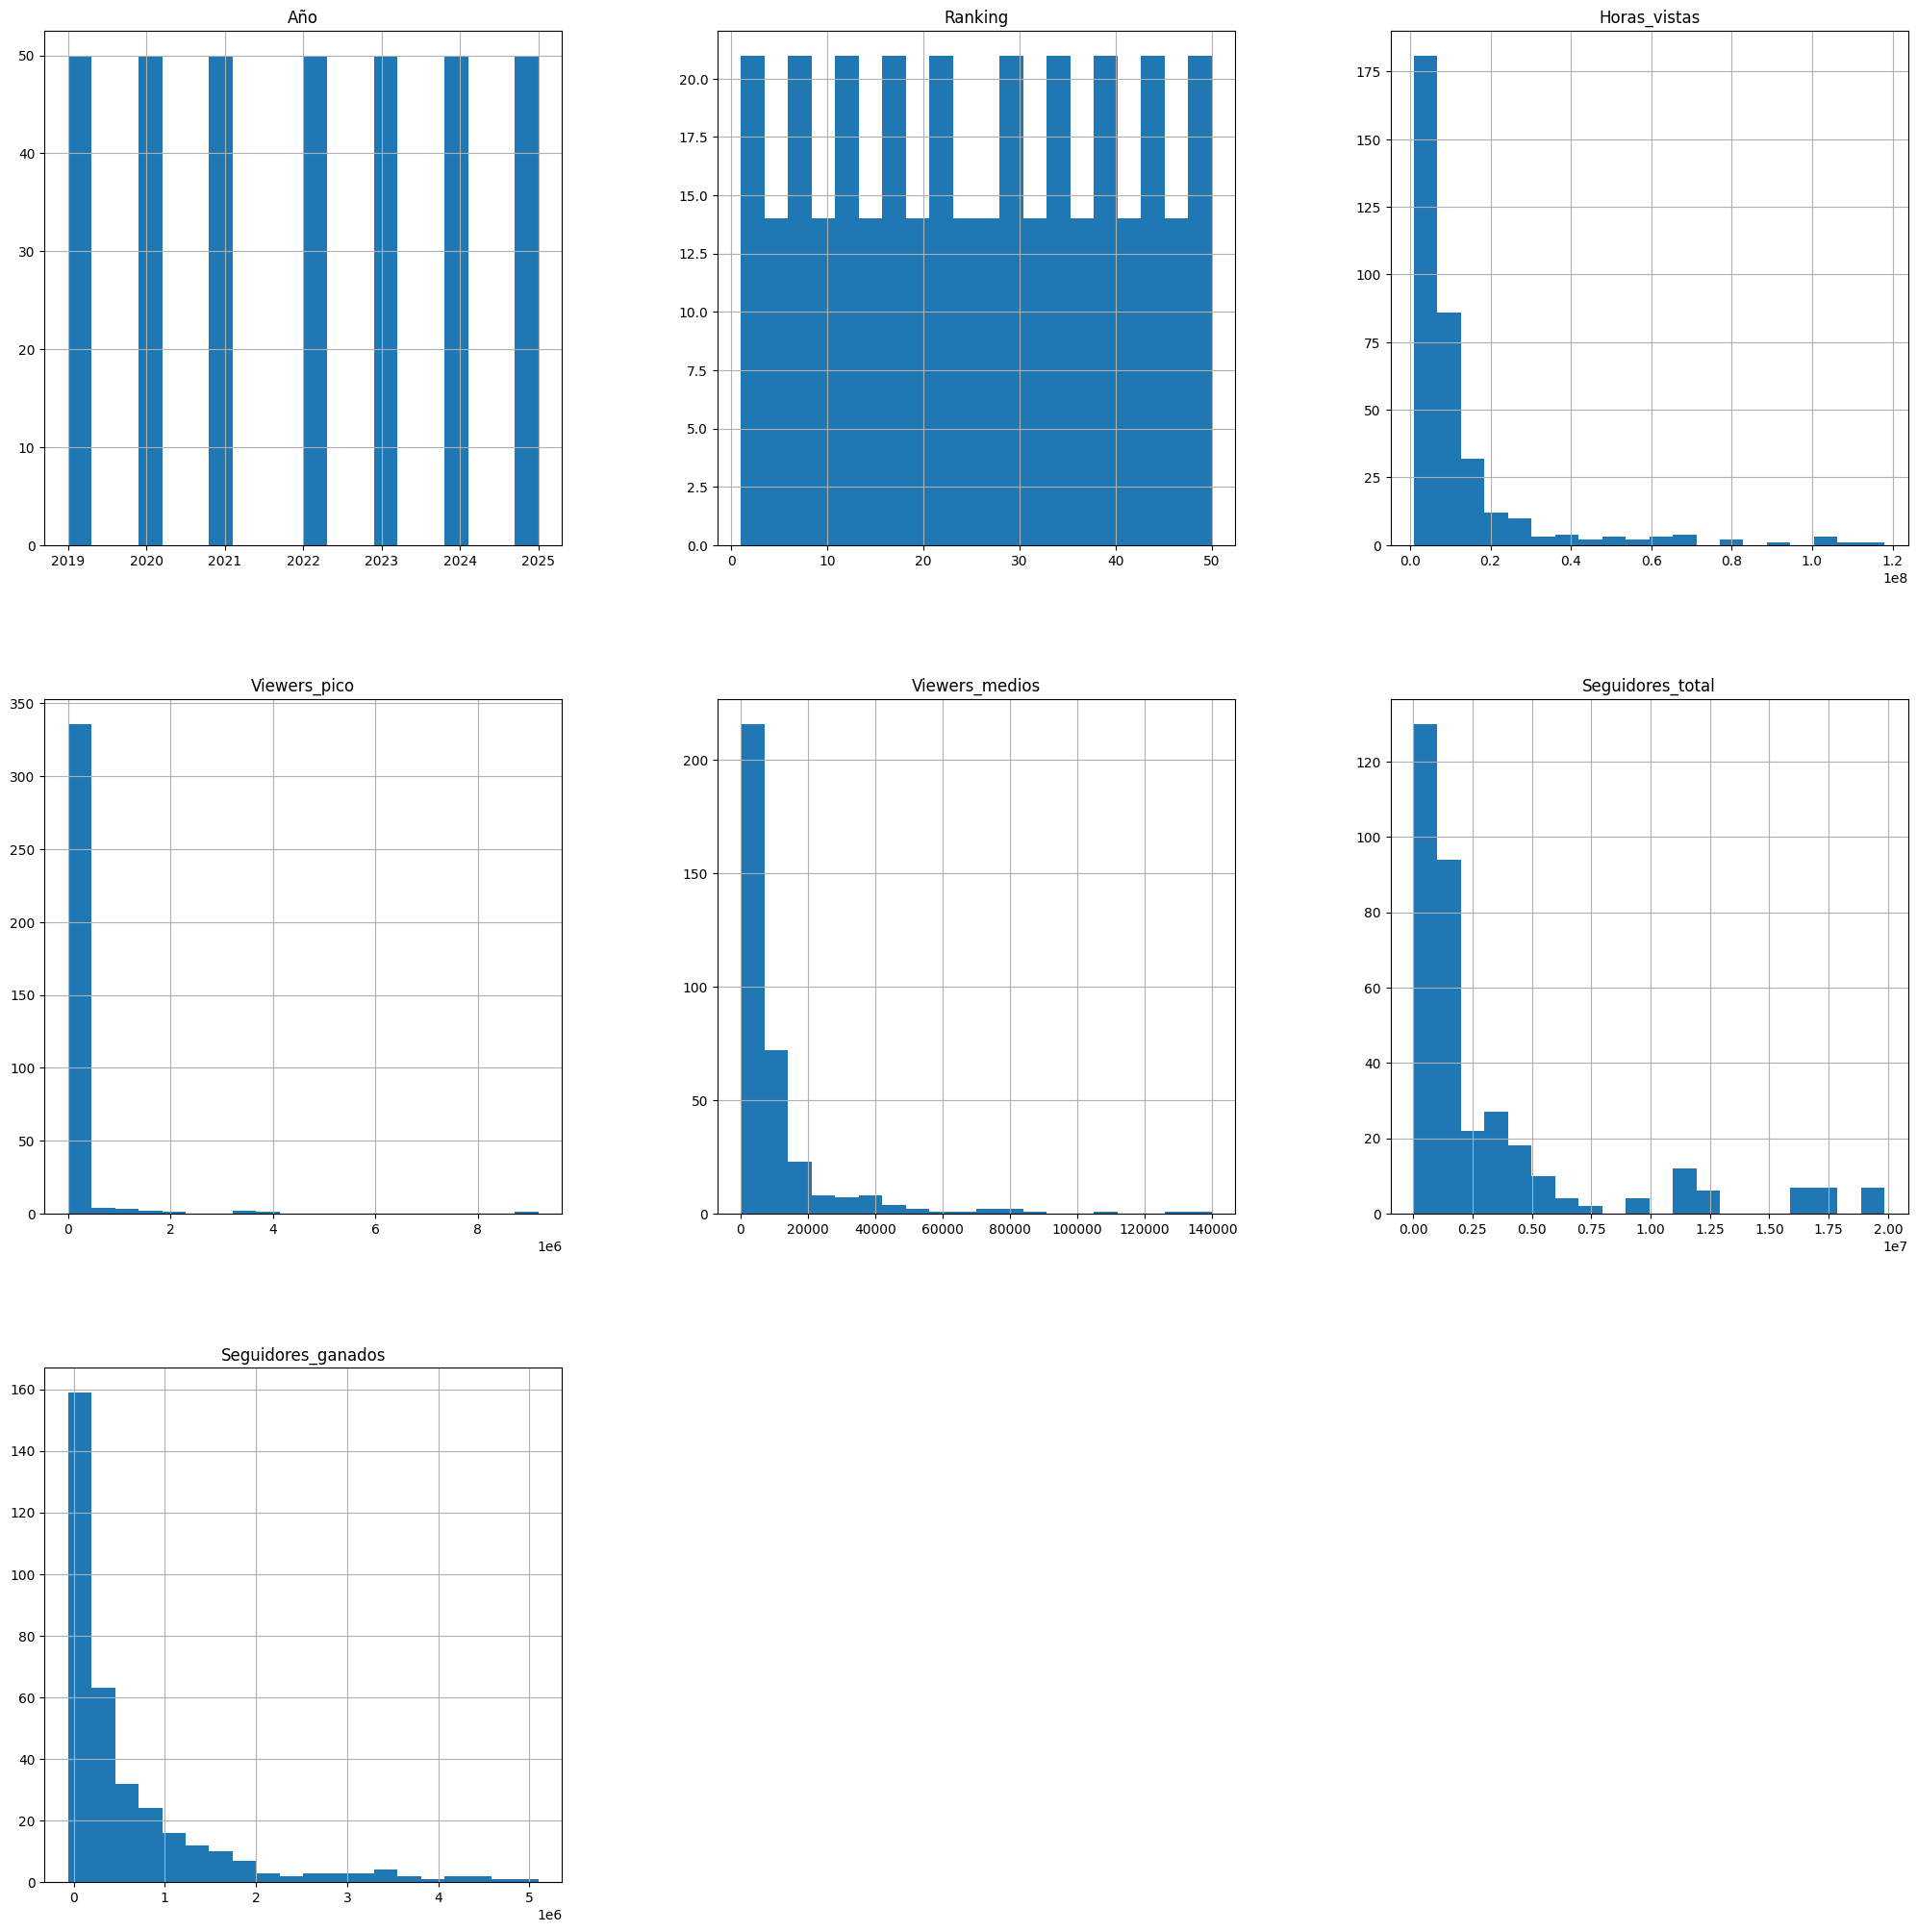

In [57]:
#miramos un poquito las variables numéricas con histogramas.
print("📉 Histogramas de columnas numéricas:")
df.hist(bins=20, figsize=(25,25))